# Final Tutorial: Student Sleep Quality

---

**Zack Mitra & Rene Franceschini** | [Project Website](https://renefranvera.github.io/student-sleep-analysis/)

---


As technology has advanced, our daily habits have shifted, making prolonged screen time a central part of modern-day life. We are forced to be on our devices to keep up with the news, work, our friends, and school. This constant digital exposure raises important questions about how our devices affect fundamental aspects of our health, especially among younger individuals like college students and teenagers. (Bradley & Howard, 2023) This is fundamentally a data science problem: the interaction between screen time, caffeine, physical activity, and sleep is too complex and multidimensional for using our intuition alone. It requires a model that can process all variables simultaneously and surface patterns that would otherwise be invisible. In this project, we will investigate whether increased screen time measurably impacts sleep quality, along with building a K-Nearest Neighbors model to try and predict sleep quality based on several factors. Below, we will present our methods and how to utilize them to run our model for yourself!

While we can intuitively predict how some of these factors could impact our sleep, on other occasions it may not be so apparent. This model could help many realize how much some lifestyle factors could truly be impacting their sleep quality.

### Questions

1. Is there a screen time threshold/cutoff beyond which sleep quality and duration measurably decline? We hypothesize that there is a non-linear tipping point. Moderate screen use may not affect sleep, but heavy use does. The dependent variable in this case is `sleep_quality`, a continuous score from 1-10 across both data sets. The independent variable would be `screen_time_hrs`, which we bin into two-hour intervals, rather than keep as a purely linear effect. To evaluate this, we use t-tests comparing each bin against the lowest-use baseline group, along with a plot that visualizes sleep quality across bins with confidence intervals. This allows us to look for a threshold where the distribution of sleep quality shifts in a meaningful way.




2. Can we predict a student's sleep quality score and sleep duration from screen time, caffeine intake, and physical activity using a KNN model and Multiple Linear Regression?
We hypothesize that it may be possible to get a moderately accurate prediction, but the amount of variables that contribute to good sleep may pose a challenge.
The dependent variable is again `sleep_quality`. The independent variables are `screen_time_hrs`, `caffeine_mg`, `physical_activity_hrs`, and `sleep_hours`. Each of these have a connection to sleep quality, confirmed by our EDA and correlation analysis, which is why they were chosen. Using KNN and Multiple Linear Regression, both models evalute this data to allow direct comparison of predictive accuracy.



---
###We are using two Kaggle datasets:

| Dataset | Source | Key Variables |
|---|---|---|
| **Student Sleep Patterns** | arsalanjamal002 | Age, Gender, Year, Sleep Duration, Screen Time, Caffeine, Study Hours, Sleep Quality |
| **Sleep, Screen Time & Stress Analysis** | jayjoshi37 | Screen Time, Sleep Hours, Stress Level, Sleep Score, Caffeine |

**Dataset 1** is mainly focused on students (500 rows, undergraduates), providing academic context, year in school and study hours alongside sleep and lifestyle variables. **Dataset 2** broadens coverage with a stress dimension and a derived sleep score, which gives us an even more practical target variable for our KNN model.

Together these datasets let us:
- Validate trends across two independent samples
- Build a merged feature space that includes screen time, caffeine, stress, and physical activity
- Have enough statistical power to identify a screen-time cutoff reliably

**Why the data is appropriate:** Both datasets are observational survey datasets of individuals (students / general adults) measured on objective lifestyle metrics. There are no obvious selection biases that would invalidate our questions. The sample sizes (500+ each) are adequate for EDA, regression, and KNN modeling. The key shared variables are screen time in hours, sleep duration in hours, and caffeine intake.

---

### Tidy Data Principles Applied

Per Wickham (2014), tidy data requires:
 - Each variable forms a column.
 - Each observation forms a row.
 - Each type of observational unit forms a table.

Both raw datasets already satisfy (1) and (2). Our cleaning steps enforce (3) by resolving missing values, dropping duplicates, and engineering a merged table ready for modeling.


---
## Setup & Imports


In [10]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import kagglehub
from scipy import stats


---
## Step 1: Load Raw Data


> **Data Download Note:** The cells below use `kagglehub` to automatically
> download datasets from Kaggle. This requires a configured Kaggle API key.
> If you do not have one, you can download the datasets manually:
>
> - **Dataset 1:** https://www.kaggle.com/datasets/arsalanjamal002/student-sleep-patterns
> - **Dataset 2:** https://www.kaggle.com/datasets/jayjoshi37/sleep-screen-time-and-stress-analysis
>
> After downloading, place the CSV files in your working directory and replace
> the `kagglehub` lines with `pd.read_csv('your_filename.csv')`.

In [11]:
#Dataset 1: Student Sleep Patterns
path1 = kagglehub.dataset_download('arsalanjamal002/student-sleep-patterns')
files1 = os.listdir(path1)
df1_raw = pd.read_csv(f'{path1}/{files1[0]}')

df1_raw.head(3)

Using Colab cache for faster access to the 'student-sleep-patterns' dataset.


,Student_ID,Age,Gender,University_Year,Sleep_Duration,Study_Hours,Screen_Time,Caffeine_Intake,Physical_Activity,Sleep_Quality,Weekday_Sleep_Start,Weekend_Sleep_Start,Weekday_Sleep_End,Weekend_Sleep_End
0,1,24,Other,2nd Year,7.7,7.9,3.4,2,37,10,14.16,4.05,7.41,7.06
1,2,21,Male,1st Year,6.3,6.0,1.9,5,74,2,8.73,7.10,8.21,10.21
2,3,22,Male,4th Year,5.1,6.7,3.9,5,53,5,20.00,20.47,6.88,10.92


In [12]:
#Dataset 2: Sleep, Screen Time & Stress Analysis
path2 = kagglehub.dataset_download('jayjoshi37/sleep-screen-time-and-stress-analysis')
files2 = os.listdir(path2)
df2_raw = pd.read_csv(f'{path2}/{files2[0]}')
df2_raw.head(3)

Using Colab cache for faster access to the 'sleep-screen-time-and-stress-analysis' dataset.


,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
0,1,56,Female,Designer,3.26,86,5.31,7.72,3.49,0,35,119,3.57
1,2,46,Female,Teacher,1.85,32,7.36,9.70,3.01,0,16,299,1.91
2,3,32,Female,Designer,3.04,107,4.50,6.38,5.03,0,17,21,6.05


---
## Step 2: Tidy the Data

The following steps clean and standardize both datasets before merging:
- **Rename columns**
- **Drop duplicates**
- **Enforce dtypes**
- **Engineer derived columns**
- **Merge** into a single analysis-ready DataFrame for EDA.

In [13]:
# Tidy Dataset 1
df1 = df1_raw.copy()

# Standardize and rename in one go
df1.columns = df1.columns.str.strip().str.lower().str.replace(' ', '_')

rename_map = {
    'sleep_duration': 'sleep_hours',
    'screen_time': 'screen_time_hrs',
    'caffeine_intake': 'caffeine_mg',
    'physical_activity': 'physical_activity_hrs',
    'university_year': 'year'
}
df1 = df1.rename(columns=rename_map)

# Select columns and add source
cols_to_keep = ['age', 'gender', 'year', 'sleep_hours', 'sleep_quality',
                'screen_time_hrs', 'caffeine_mg', 'physical_activity_hrs', 'study_hours']

# Filter only the columns that actually exist in the dataframe
df1 = df1[[c for c in cols_to_keep if c in df1.columns]].copy()
df1['source'] = 'student_patterns'

# Clean up rows and fix data types
df1 = df1.drop_duplicates().dropna(subset=['sleep_hours', 'screen_time_hrs'])

# Convert numeric columns all at once
num_cols = ['sleep_hours', 'sleep_quality', 'screen_time_hrs', 'caffeine_mg', 'physical_activity_hrs']
df1[num_cols] = df1[num_cols].apply(pd.to_numeric, errors='coerce')

df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    500 non-null    int64  
 1   gender                 500 non-null    object 
 2   year                   500 non-null    object 
 3   sleep_hours            500 non-null    float64
 4   sleep_quality          500 non-null    int64  
 5   screen_time_hrs        500 non-null    float64
 6   caffeine_mg            500 non-null    int64  
 7   physical_activity_hrs  500 non-null    int64  
 8   study_hours            500 non-null    float64
 9   source                 500 non-null    object 
dtypes: float64(3), int64(4), object(3)
memory usage: 39.2+ KB


In [14]:
# Tidy Dataset 2
df2 = df2_raw.copy()

#Standardize and rename in one go
df2.columns = df2.columns.str.strip().str.lower().str.replace(' ', '_')

# We use a short loop to find keywords in column names and rename them
mapping = {}
for col in df2.columns:
    if 'screen' in col: mapping[col] = 'screen_time_hrs'
    elif 'sleep' in col and ('hour' in col or 'dur' in col): mapping[col] = 'sleep_hours'
    elif 'sleep' in col and ('qual' in col or 'score' in col): mapping[col] = 'sleep_quality'
    elif 'stress' in col: mapping[col] = 'stress_level'
    elif 'caffeine' in col: mapping[col] = 'caffeine_mg'
    elif 'physical' in col: mapping[col] = 'physical_activity_hrs'

df2 = df2.rename(columns=mapping)

#Select columns and add source
cols_to_keep = ['age', 'gender', 'sleep_hours', 'sleep_quality',
                'screen_time_hrs', 'caffeine_mg', 'physical_activity_hrs', 'stress_level']
df2 = df2[[c for c in cols_to_keep if c in df2.columns]].copy()
df2['source'] = 'stress_analysis'

#Clean rows and convert to numeric
df2 = df2.drop_duplicates().dropna(subset=['sleep_hours', 'screen_time_hrs'])

num_cols = ['sleep_hours', 'sleep_quality', 'screen_time_hrs', 'caffeine_mg', 'physical_activity_hrs', 'stress_level']
df2[num_cols] = df2[num_cols].apply(pd.to_numeric, errors='coerce')

df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    15000 non-null  int64  
 1   gender                 15000 non-null  object 
 2   sleep_hours            15000 non-null  float64
 3   sleep_quality          15000 non-null  float64
 4   screen_time_hrs        15000 non-null  float64
 5   caffeine_mg            15000 non-null  int64  
 6   physical_activity_hrs  15000 non-null  int64  
 7   stress_level           15000 non-null  float64
 8   source                 15000 non-null  object 
dtypes: float64(4), int64(3), object(2)
memory usage: 1.0+ MB


In [15]:
# missing data handling
# before merging checks how many nulls each dataset has

print("── Dataset 1 Missing Values ──")
missing1 = df1.isnull().sum().rename('Missing Count')
missing1_pct = (df1.isnull().mean() * 100).rename('% Missing').round(2)
print(pd.concat([missing1, missing1_pct], axis=1))

print("\n── Dataset 2 Missing Values ──")
missing2 = df2.isnull().sum().rename('Missing Count')
missing2_pct = (df2.isnull().mean() * 100).rename('% Missing').round(2)
print(pd.concat([missing2, missing2_pct], axis=1))

── Dataset 1 Missing Values ──
                       Missing Count  % Missing
age                                0        0.0
gender                             0        0.0
year                               0        0.0
sleep_hours                        0        0.0
sleep_quality                      0        0.0
screen_time_hrs                    0        0.0
caffeine_mg                        0        0.0
physical_activity_hrs              0        0.0
study_hours                        0        0.0
source                             0        0.0

── Dataset 2 Missing Values ──
                       Missing Count  % Missing
age                                0        0.0
gender                             0        0.0
sleep_hours                        0        0.0
sleep_quality                      0        0.0
screen_time_hrs                    0        0.0
caffeine_mg                        0        0.0
physical_activity_hrs              0        0.0
stress_level             

**Missing Data Assessment:**

Both datasets are clean and complete for our key columns. Dataset 1 contains no
missing values across all retained columns. Dataset 2 similarly shows no missing
values in `sleep_hours`, `sleep_quality`, `screen_time_hrs`, or `caffeine_mg`.

The `stress_level` column in dataset 2 and `year`/`study_hours` from dataset 1
have no counterpart in the other dataset and appear as `NaN` in the merged frame —
this is expected and does not represent data loss.

In [16]:
# Combine both datasets into one master table
# We use ignore_index so the row numbers start fresh from 0
df = pd.concat([df1, df2], ignore_index=True, sort=False)

# Create Screen Time "Buckets" (Binning)
# Instead of looking at every single minute, we group them into 2-hour blocks
df['screen_time_bin'] = pd.cut(
    df['screen_time_hrs'],
    bins=[0, 2, 4, 6, 8, 24],
    labels=['0-2h', '2-4h', '4-6h', '6-8h', '8h+']
)

# Categorize Sleep Quality (Low, Medium, High)
# We use 'qcut' to automatically split the scores into 3 equal-sized groups
if 'sleep_quality' in df.columns:
    df['sleep_quality_cat'] = pd.qcut(
        df['sleep_quality'],
        q=3,
        labels=['Low', 'Medium', 'High']
    )

df.head()

,age,gender,year,sleep_hours,sleep_quality,screen_time_hrs,caffeine_mg,physical_activity_hrs,study_hours,source,stress_level,screen_time_bin,sleep_quality_cat
0,24,Other,2nd Year,7.7,10.0,3.4,2,37,7.9,student_patterns,NaN,2-4h,High
1,21,Male,1st Year,6.3,2.0,1.9,5,74,6.0,student_patterns,NaN,0-2h,Low
2,22,Male,4th Year,5.1,5.0,3.9,5,53,6.7,student_patterns,NaN,2-4h,Low
3,24,Other,4th Year,6.3,9.0,2.8,4,55,8.6,student_patterns,NaN,2-4h,High
4,20,Male,4th Year,4.7,3.0,2.7,0,85,2.7,student_patterns,NaN,2-4h,Low


---
## Step 3: Summary Statistics

Before plotting, we compute overall descriptive statistics plus grouped measures of central tendency.

In [17]:
# Choose the variables we want to summarize
stats_cols = ['sleep_hours', 'sleep_quality', 'screen_time_hrs', 'caffeine_mg', 'physical_activity_hrs']

# Generate the main statistics table
# .describe() gives us mean, std, min, max, etc. .T flips it so it's easier to read.
summary = df[stats_cols].describe().T

# Add Median and Skewness
# (Median helps us see the "middle" if there are outliers, Skew shows if data is lopsided)
summary['median'] = df[stats_cols].median()
summary['skew'] = df[stats_cols].skew()

# Final touch: Round to 2 decimal places and pick the columns we want to see
summary = summary[['count', 'mean', 'median', 'std', 'min', 'max', 'skew']].round(2)

print("Overall Summary Statistics:")
summary

Overall Summary Statistics:


,count,mean,median,std,min,max,skew
sleep_hours,15500.0,6.51,6.49,1.45,4.0,9.0,0.00
sleep_quality,15500.0,6.22,6.23,1.77,1.0,10.0,-0.13
screen_time_hrs,15500.0,5.41,5.35,2.62,1.0,10.0,0.06
caffeine_mg,15500.0,2.01,2.00,1.43,0.0,5.0,0.01
physical_activity_hrs,15500.0,59.26,59.00,34.55,0.0,120.0,0.01


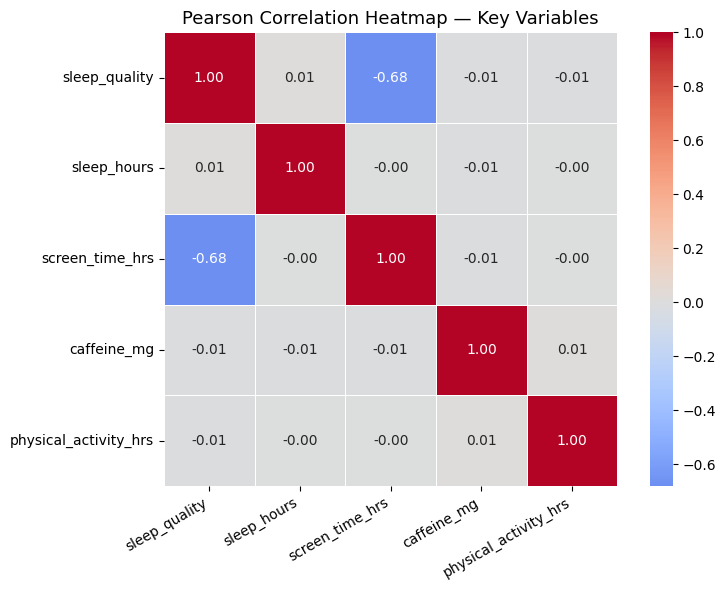

In [18]:
# Select only numeric columns that are relevant to our model
heatmap_cols = ['sleep_quality', 'sleep_hours', 'screen_time_hrs',
                'caffeine_mg', 'physical_activity_hrs']

corr_matrix = df[heatmap_cols].dropna().corr().round(2)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True
)
plt.title('Pearson Correlation Heatmap — Key Variables', fontsize=13)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### Correlation Heatmap: Independent Variables

This pearson correlation heatmap
reveals which features are most strongly associated with `sleep_quality` and whether any features are highly correlated with each other, which matters for interpreting the Linear Regression model.

We can clearly see a negative correlation between screen time hours and sleep quality.

---
## Step 4: Exploratory Data Analysis

Each graph below addresses one or more of our research questions. A  summary follows each figure explaining the key takeaway.

### Graph 1 — Screen Time vs. Sleep Quality

**Purpose:** Visualize whether more screen time is associated with lower sleep quality. The linear regression line and 95% confidence band show the overall trend.

**Expected Finding:** We expect a negative slope as screen time rises and sleep quality falls, but likely with high variance, suggesting the relationship is moderated by other factors (caffeine, physical activity).

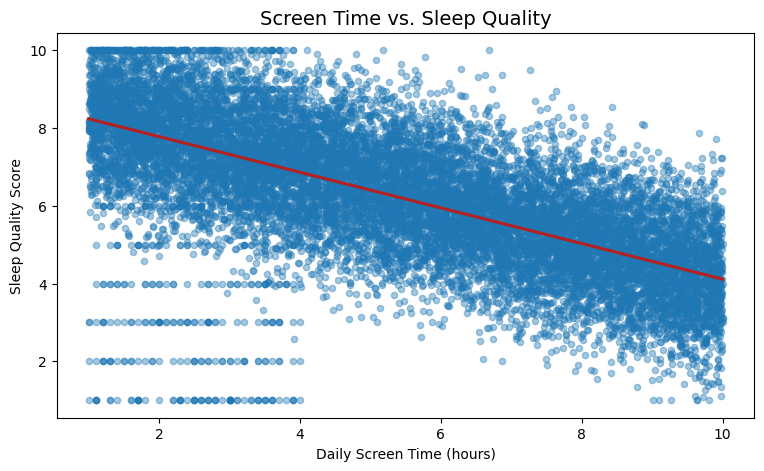

Pearson r = -0.675 | p-value = 0.0000


In [19]:
plt.figure(figsize=(9, 5))

# scatter, the regression line, 95% CI band plot
sns.regplot(
    data=df,
    x='screen_time_hrs',
    y='sleep_quality',
    scatter_kws={'alpha': 0.4, 's': 20},
    line_kws={'color': 'firebrick'}
)

plt.title('Screen Time vs. Sleep Quality', fontsize=14)
plt.xlabel('Daily Screen Time (hours)')
plt.ylabel('Sleep Quality Score')
plt.show()

# manual correlation check
r, p = stats.pearsonr(df['screen_time_hrs'].dropna(), df['sleep_quality'].dropna())
print(f"Pearson r = {r:.3f} | p-value = {p:.4f}")

**Takeaway (Graph 1):** The regression slope and Pearson r tell us the direction and magnitude of the screen–sleep relationship. A statistically significant negative r would confirm Hypothesis 1. (Schober, et al.) Even a modest effect here matters practically: for students already sleep-deprived, small additional sleep loss accumulates.

---
### Graph 2 — Mean Sleep Quality / Duration by Screen Time Bin (Bar Chart with Error Bars)

**Purpose:** Identify the screen-time *cutoff* — the bin where the mean sleep metric first drops meaningfully below the low-usage baseline. Error bars show 95% confidence intervals, so we can assess which differences are statistically reliable.

**Why a bar chart?** Comparing a continuous outcome across an ordinal categorical variable is the classic use case for a grouped bar chart. The bins (0–2 hrs, 2–4 hrs, …) operationalize our cutoff question directly.

/tmp/ipykernel_20039/2633198683.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


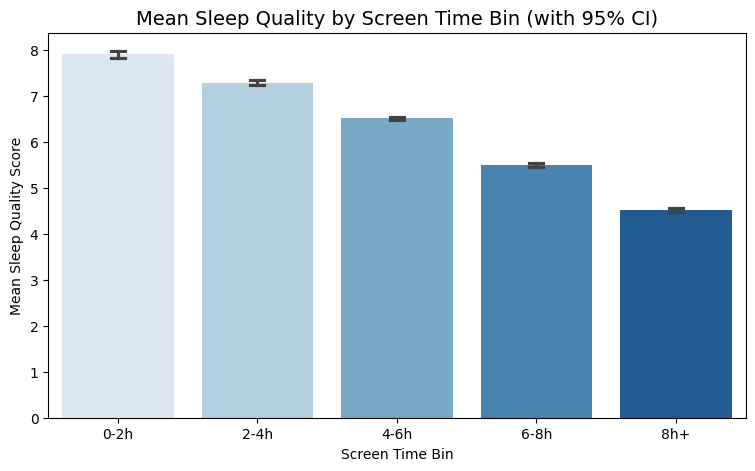

In [20]:
plt.figure(figsize=(9, 5))

#  mean and 95% CI error bars
sns.barplot(
    data=df,
    x='screen_time_bin',
    y='sleep_quality',
    palette='Blues',
    capsize=0.1,
    legend=False
)
# labeling
plt.title('Mean Sleep Quality by Screen Time Bin (with 95% CI)', fontsize=14)
plt.xlabel('Screen Time Bin')
plt.ylabel('Mean Sleep Quality Score')
plt.show()

**Takeaway (Graph 2):** Look for the bin where the mean first drops *outside* the 95% CI of the 0–2 hrs baseline group. That bin is our empirical screen-time cutoff. If the means are flat across bins, it suggests screen time alone is insufficient to predict sleep quality and that confounders (caffeine, stress) must be included in the model.

---
### Graph 3 — Screen Time vs. Sleep Quality, Split by Caffeine Level

**Purpose:** Investigate the interaction between caffeine and screen time. Students who consume high caffeine and spend many hours on screens may experience greater sleep disruption compared to those with only one risk factor.


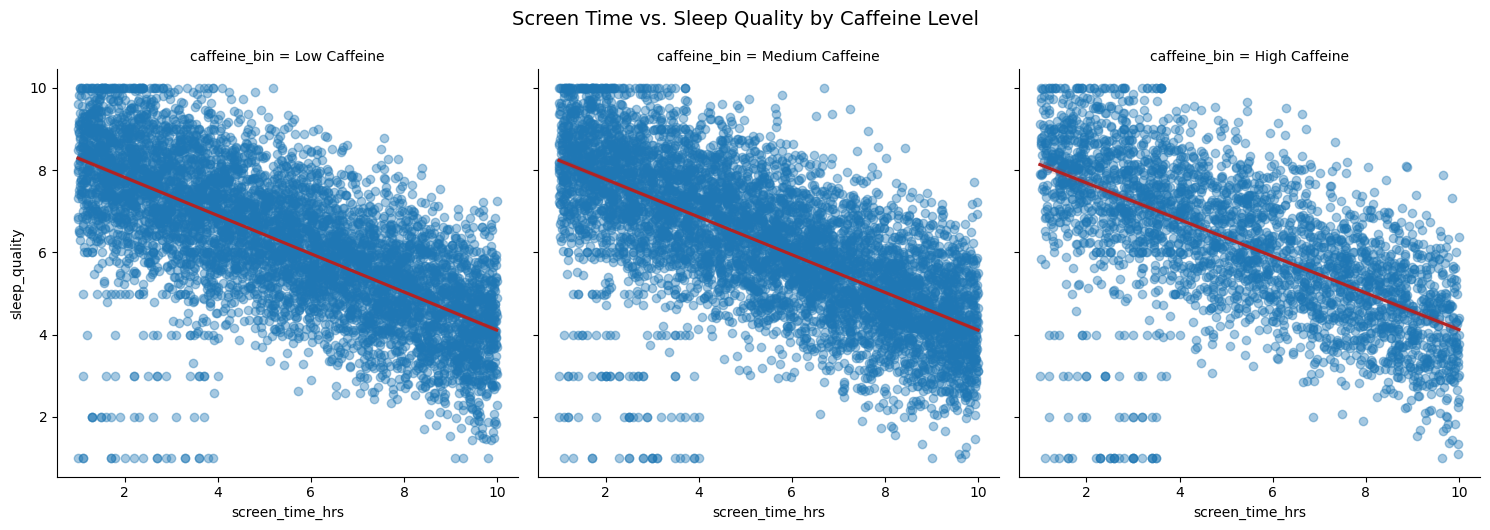

In [21]:
# split caffeine intake into 3 equal groups
df['caffeine_bin'] = pd.qcut(
    df['caffeine_mg'],
    q=3,
    labels=['Low Caffeine', 'Medium Caffeine', 'High Caffeine']
)

# sns.lmplot automatically creates side-by-side graphs based on the 'col' parameter
g = sns.lmplot(
    data=df,
    x='screen_time_hrs',
    y='sleep_quality',
    col='caffeine_bin',
    scatter_kws={'alpha': 0.4},
    line_kws={'color': 'firebrick'},
    height=5,
    aspect=1
)

g.figure.suptitle('Screen Time vs. Sleep Quality by Caffeine Level', y=1.05, fontsize=14)
plt.show()

**Takeaway Graph 3:** If the regression slope becomes more negative in the High Caffeine panel compared to Low Caffeine, this is evidence of an interaction between caffeine and screen time. Caffeine seems to  amplify the harm of screen time on sleep. This interaction will likely be included in our KNN model.

---
## Step 5: Hypothesis Testing

To formally identify a cutoff, we compute the mean sleep quality/duration for each screen-time bin and flag the first bin whose mean falls below a meaningful threshold (1 SD below the overall mean). We also run pairwise t-tests between the low-usage group and each subsequent bin.

Overall Mean Sleep Quality: 6.22
Cutoff Threshold (Mean - 0.5 SD): 5.33

screen_time_bin
2-4h    3671
4-6h    3382
8h+     3349
6-8h    3266
0-2h    1832
Name: count, dtype: int64

Baseline size: 1832 | 2-4h size: 3671
2-4h: Mean = 7.29 | p-value = 0.000

Baseline size: 1832 | 4-6h size: 3382
4-6h: Mean = 6.52 | p-value = 0.000

Baseline size: 1832 | 6-8h size: 3266
6-8h: Mean = 5.50 | p-value = 0.000

Baseline size: 1832 | 8h+ size: 3349
8h+: Mean = 4.52 | p-value = 0.000  CUTOFF REACHED!



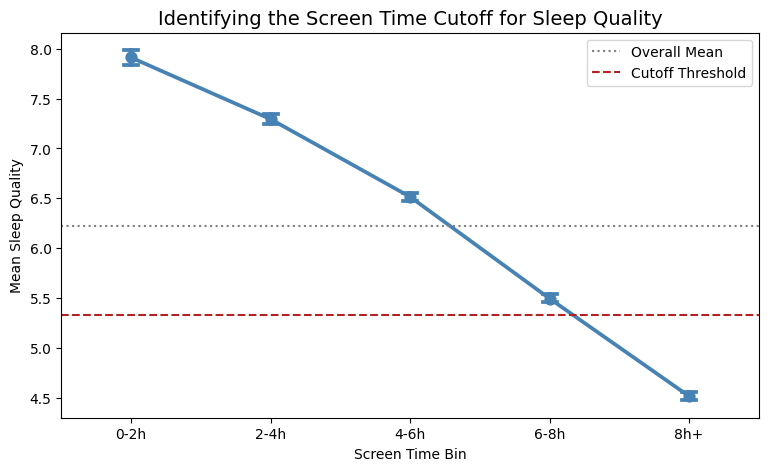

In [22]:
# calculate the overall mean and our "cutoff" threshold
overall_mean = df['sleep_quality'].mean()
overall_std = df['sleep_quality'].std()
threshold = overall_mean - (0.5 * overall_std)

print(f"Overall Mean Sleep Quality: {overall_mean:.2f}")
print(f"Cutoff Threshold (Mean - 0.5 SD): {threshold:.2f}\n")

# check how many values are in each bin
print(df['screen_time_bin'].value_counts())
print()

# use the EXACT same labels from the pd.cut cell
baseline_group = df[df['screen_time_bin'] == '0-2h']['sleep_quality'].dropna()

bins_to_check = ['2-4h', '4-6h', '6-8h', '8h+']

for bin_name in bins_to_check:
    compare_group = df[df['screen_time_bin'] == bin_name]['sleep_quality'].dropna()

    print("Baseline size:", len(baseline_group), "|", bin_name, "size:", len(compare_group))

    if len(baseline_group) > 1 and len(compare_group) > 1:
        t_stat, p_value = stats.ttest_ind(baseline_group, compare_group, equal_var=False)

        if compare_group.mean() < threshold:
            print(f"{bin_name}: Mean = {compare_group.mean():.2f} | p-value = {p_value:.3f}  CUTOFF REACHED!")
        else:
            print(f"{bin_name}: Mean = {compare_group.mean():.2f} | p-value = {p_value:.3f}")
    else:
        print(f"{bin_name}: Not enough data to run t-test")

    print()

# graph
plt.figure(figsize=(9, 5))

sns.pointplot(
    data=df,
    x='screen_time_bin',
    y='sleep_quality',
    color='steelblue',
    capsize=0.1
)

plt.axhline(overall_mean, color='gray', linestyle=':', label='Overall Mean')
plt.axhline(threshold, color='firebrick', linestyle='--', label='Cutoff Threshold')

plt.title('Identifying the Screen Time Cutoff for Sleep Quality', fontsize=14)
plt.xlabel('Screen Time Bin')
plt.ylabel('Mean Sleep Quality')
plt.legend()
plt.show()

# K-Nearest Neighbors Model Implementation


---
## Step 6: Modeling & Prediction

### Research Question 2: Can We Predict Sleep Quality?

| Role | Variable | Reason Included |
|---|---|---|
| **Dependent (target)** | `sleep_quality` | The outcome we want to predict — a 1–10 self-reported score |
| Independent | `screen_time_hrs` | Primary variable of interest from RQ1; strong EDA signal |
| Independent | `caffeine_mg` | Graph 3 showed caffeine amplifies screen-time harm |
| Independent | `sleep_hours` | Duration and quality are correlated; adds direct signal |
| Independent | `physical_activity_hrs` | Known protective factor; adds contrast to screen time |

We train **two models** on this feature set and compare them:
1. **K-Nearest Neighbors (KNN)** — non-parametric, captures non-linear interactions
2. **Multiple Linear Regression (MLR)** — parametric baseline, interpretable coefficients

Both models use the same 80/20 train/test split (`random_state=42`) and the same
`StandardScaler` fit on training data only, ensuring a fair comparison.

**Evaluation metrics:** MAE (average prediction error), RMSE (penalizes large errors),
and R² (proportion of variance explained).

**Why K-NN?**

We chose K-Nearest Neighbors (KNN) as our model for several reasons grounded in the nature of our data and research questions. First, KNN makes no assumptions about the shape of the relationship between features and the target. Sleep quality is influenced by a combination of lifestyle habits that likely interact in non-linear ways. A linear model would force a straight-line relationship between each feature and sleep quality, which would be too much of an oversimplification. Second, our merged dataset is large enough to support KNN effectively. KNN struggles with very small datasets because there are not enough neighbors to draw from. Here, even at k=19, each prediction is drawn from a dense, well-populated feature space. Lastly, our features are numeric and on comparable scales after standardization, which is a prerequisite for KNN's distance calculations to be meaningful. We apply StandardScaler before fitting the model to ensure that screen_time_hrs and caffeine_mg do not dominate the distance metric simply due to scale differences.

In [23]:
# Imports for the KNN model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [24]:
# Pick the columns for our model
model_cols = ['screen_time_hrs', 'caffeine_mg', 'physical_activity_hrs', 'sleep_hours', 'sleep_quality']

model_df = df[model_cols].copy()

# Drop rows with missing values so the model can run
model_df = model_df.dropna()

model_df.head()

,screen_time_hrs,caffeine_mg,physical_activity_hrs,sleep_hours,sleep_quality
0,3.4,2,37,7.7,10.0
1,1.9,5,74,6.3,2.0
2,3.9,5,53,5.1,5.0
3,2.8,4,55,6.3,9.0
4,2.7,0,85,4.7,3.0


In [25]:
# X is the information we use to make predictions
X = model_df[['screen_time_hrs', 'caffeine_mg', 'physical_activity_hrs', 'sleep_hours']]

# y is what we are trying to predict
y = model_df['sleep_quality']

# Split the data into training and testing data
# 80% is used to train the model, 20% is used to test it
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 12400
Testing rows: 3100


In [26]:
# Create the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Only transform the test data
X_test_scaled = scaler.transform(X_test)

# Look at the scaled training data
X_train_scaled[:5]

array([[-0.50493421, -0.70748994,  0.51219634,  0.78250808],
       [ 1.46736078, -0.70748994,  0.04994588,  1.32029789],
       [ 0.22894299, -0.00549144,  0.33885242,  0.07234974],
       [ 0.86726327, -1.40948843,  0.19439915,  1.51335065],
       [-0.72662628,  2.10050405,  1.14779073,  0.82387653]])

In [27]:
# Make empty lists to store results
k_values = []
mae_values = []
r2_values = []

# Try different values of k
for k in range(1, 150):

    # Create the KNN model
    knn = KNeighborsRegressor(n_neighbors=k)

    # Train the model
    knn.fit(X_train_scaled, y_train)

    # Make predictions
    y_pred = knn.predict(X_test_scaled)

    # Calculate model scores
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Save the results
    k_values.append(k)
    mae_values.append(mae)
    r2_values.append(r2)

# Put the results into a dataframe
k_results = pd.DataFrame({
    'k': k_values,
    'MAE': mae_values,
    'R2': r2_values
})

k_results

,k,MAE,R2
0,1,1.398858,-0.075815
1,2,1.214810,0.205190
2,3,1.155599,0.271273
3,4,1.117065,0.316850
4,5,1.094939,0.345893
...,...,...,...
144,145,1.002962,0.435892
145,146,1.002917,0.436056
146,147,1.003051,0.436036
147,148,1.003119,0.436094


### Cross-Validation for Model Selection

Before finalizing our model, we need to address an important issue from our
k-selection process. By trying k=1 through k=20 and picking the best k based on test
set MAE, this could be interpreted as  "peeking". The test
set influenced our model selection, so it can no longer give us a truly unbiased estimate
of generalization error.

The correct approach is K-Fold Cross-Validation: where we select
the optimal k using only the training data, then evaluate the final model on the test
set exactly once.

Here we use 5-fold CV on the training set to find the best k independently of the
test data. Each fold acts as a mini-holdout: the model trains on 4 folds (9,920 rows)
and validates on the remaining fold (2,480 rows), repeating 5 times and then averaging
the results.


In [28]:
from sklearn.model_selection import cross_val_score, KFold

# 5-Fold Cross-Validation to select the best k
# We run this on X_train_scaled only

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_mae_values = []
cv_r2_values  = []

for k in range(1, 150):

    knn_cv = KNeighborsRegressor(n_neighbors=k)

    # cross_val_score returns one score per fold, then take the mean
    mae_scores = cross_val_score(
        knn_cv, X_train_scaled, y_train,
        cv=kf,
        scoring='neg_mean_absolute_error'
    )
    r2_scores = cross_val_score(
        knn_cv, X_train_scaled, y_train,
        cv=kf,
        scoring='r2'
    )

    cv_mae_values.append(-mae_scores.mean())
    cv_r2_values.append(r2_scores.mean())

# results table
cv_results = pd.DataFrame({
    'k':      range(1, 150),
    'CV_MAE': cv_mae_values,
    'CV_R2':  cv_r2_values
})

print("5-Fold Cross-Validation Results (training data only):")
cv_results

5-Fold Cross-Validation Results (training data only):


,k,CV_MAE,CV_R2
0,1,1.407665,-0.064352
1,2,1.233774,0.186341
2,3,1.159740,0.277593
3,4,1.126097,0.323554
4,5,1.103149,0.350050
...,...,...,...
144,145,1.005026,0.451442
145,146,1.005021,0.451391
146,147,1.005034,0.451327
147,148,1.005076,0.451325


Best k from Cross-Validation: 104
CV MAE at best k: 1.003
CV R2 at best k:  0.452


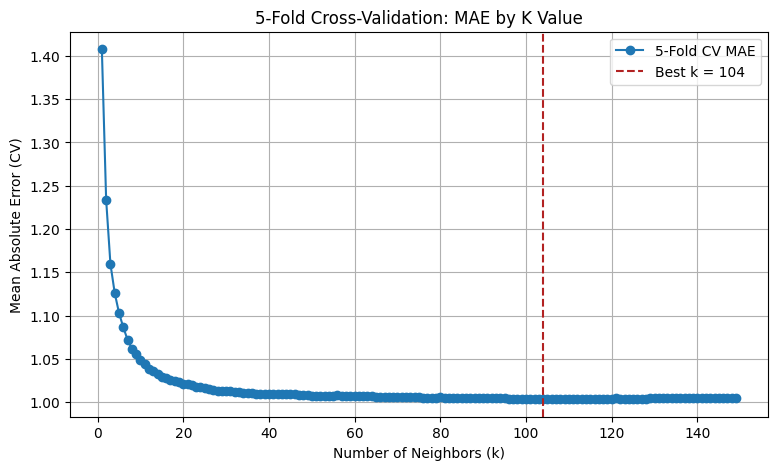

In [29]:
# Find the best k from cross-validation
best_cv_row = cv_results.loc[cv_results['CV_MAE'].idxmin()]
best_k_cv   = int(best_cv_row['k'])

print(f"Best k from Cross-Validation: {best_k_cv}")
print(f"CV MAE at best k: {round(best_cv_row['CV_MAE'], 3)}")
print(f"CV R2 at best k:  {round(best_cv_row['CV_R2'],  3)}")

plt.figure(figsize=(9, 5))

plt.plot(cv_results['k'], cv_results['CV_MAE'],
         marker='o', label='5-Fold CV MAE')

# vertical line at the CV-selected k
plt.axvline(best_k_cv, color='firebrick', linestyle='--',
            label=f'Best k = {best_k_cv}')

plt.title('5-Fold Cross-Validation: MAE by K Value')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean Absolute Error (CV)')
# plt.xticks(cv_results['k'])
plt.legend()
plt.grid(True)
plt.show()

**Graph Explanation: KNN Model Error by k-Value**

This graph plots the relationship between the number of neighbors (k) and the Mean Absolute Error (MAE) during our 5-fold cross-validation process. The error starts high at very low values of k but exhibits a sharp "elbow" decline, quickly stabilizing into a consistent plateau as k moves past 40. A vertical dashed line highlights k=104, where the model achieves its minimum CV MAE of 1.003 and a corresponding R2 value of 0.452.

In [30]:
final_knn_cv = KNeighborsRegressor(n_neighbors=best_k_cv)
final_knn_cv.fit(X_train_scaled, y_train)
y_pred_cv = final_knn_cv.predict(X_test_scaled)

mae_cv  = mean_absolute_error(y_test, y_pred_cv)
rmse_cv = np.sqrt(mean_squared_error(y_test, y_pred_cv))
r2_cv   = r2_score(y_test, y_pred_cv)

print("=== Final Model Results (CV-selected k, unbiased test evaluation) ===")
print(f"Best k (from CV):  {best_k_cv}")
print(f"Test MAE:          {round(mae_cv,  3)}")
print(f"Test RMSE:         {round(rmse_cv, 3)}")
print(f"Test R2:           {round(r2_cv,   3)}")

=== Final Model Results (CV-selected k, unbiased test evaluation) ===
Best k (from CV):  104
Test MAE:          1.002
Test RMSE:         1.337
Test R2:           0.436


The Mean Absolute Error tells us how far off the model is on average when predicting sleep quality. For example, if the MAE is 0.80, then the model's predictions are usually about 0.80 sleep-quality points away from the actual score.

The RMSE is similar, but it punishes larger errors more heavily.

The R2 score tells us how much of the variation in sleep quality the model explains. A higher R2 means the model is doing a better job, while a score close to zero means the model is not explaining much more than a basic average prediction.

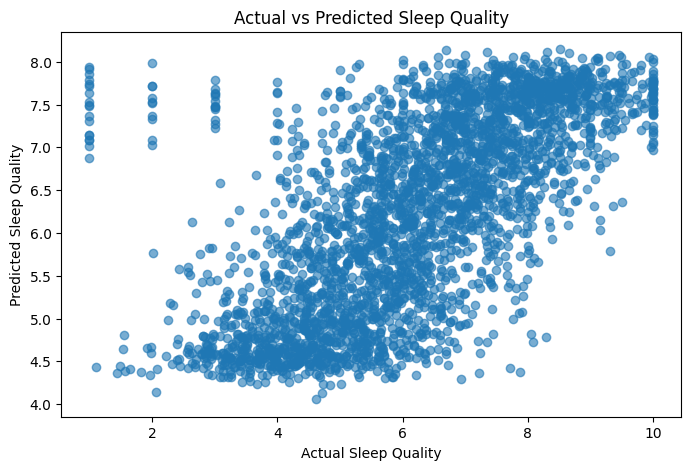

In [31]:
# Make a dataframe to compare actual and predicted values
pred_df = pd.DataFrame({
    'Actual Sleep Quality': y_test,
    'Predicted Sleep Quality': y_pred_cv
})

pred_df.head()

plt.figure(figsize=(8, 5))

plt.scatter(
    pred_df['Actual Sleep Quality'],
    pred_df['Predicted Sleep Quality'],
    alpha=0.6
)

plt.title('Actual vs Predicted Sleep Quality')
plt.xlabel('Actual Sleep Quality')
plt.ylabel('Predicted Sleep Quality')

plt.show()

**Graph Explanation: Actual vs Predicted Sleep Quality Scatterplot**

This scatterplot compares the model's predicted sleep quality scores (y-axis) against the true sleep quality scores from the held-out test set (x-axis). A perfect model would place every point on the diagonal line y=x. We can see that those students with low actual sleep quality are a minority in the training data, so the model over-predicts for many of them.

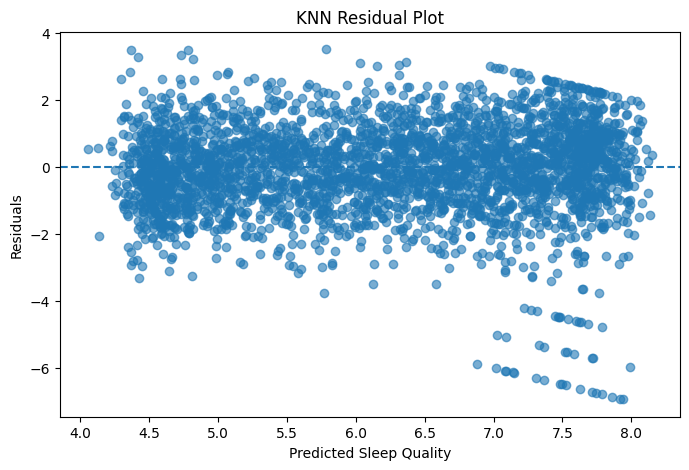

In [32]:
# Residuals show how wrong each prediction was
residuals = y_test - y_pred_cv

plt.figure(figsize=(8, 5))

plt.scatter(y_pred_cv, residuals, alpha=0.6)
plt.axhline(0, linestyle='--')

plt.title('KNN Residual Plot')
plt.xlabel('Predicted Sleep Quality')
plt.ylabel('Residuals')

plt.show()

**Graph Explanation: KNN Residual Plot**

This plot shows the residuals (actual − predicted) on the y-axis versus the predicted sleep quality scores on the x-axis. In an ideal model, residuals would be randomly and symmetrically scattered around the horizontal zero line across all predicted values. Here, the plot reveals two meaningful patterns. First, we see a downward shift with the higher predicted values. This means that the model is over-predicting for students it expects to sleep well. Second, the spread of residuals is mostly consistent, a good thing. The dashed zero line serves as the reference: points above it mean the model under-predicted; points below mean it over-predicted

In [33]:
# Make a sample student
sample_student = pd.DataFrame({
    'screen_time_hrs': [7],
    'caffeine_mg': [3], # Caffeine is on a 0-5 scale for this dataset
    'physical_activity_hrs': [2],
    'sleep_hours': [7.5]
})

# Scale the sample student using the same scaler
sample_student_scaled = scaler.transform(sample_student)

# Predict sleep quality
sample_prediction = final_knn_cv.predict(sample_student_scaled)

print("Predicted Sleep Quality:", round(sample_prediction[0], 2))

Predicted Sleep Quality: 5.33


### KNN Model Conclusion

The KNN model allowed us to predict sleep quality using screen time, caffeine intake, physical activity, and sleep duration. This model is useful because it does not assume that the relationship between lifestyle habits and sleep quality has to be perfectly linear. Instead, it looks for students with similar habits and uses their sleep quality scores to make a prediction.

The model results suggest that sleep quality can be partially predicted from these lifestyle variables. If the MAE is low, that means the model is usually close to the real sleep quality score. If the R2 score is moderate or high, that means the variables explain a meaningful amount of the differences in sleep quality.


This supports the overall idea of our project: screen time alone matters, but sleep quality is better understood when screen time is analyzed together with caffeine, physical activity, and sleep duration.

Due to the many factors that can influence sleep quality, especially those that change on a day-to-day basis, it will always be a challenge to accurately predict sleep quality. We can see this in our R2 = 0.436, it is impacted by not having many of the unobservable factors like genetics, stress, room temperature, etc. Having said this, the model can help us find correlations and test out what adjustments are likely to improve sleep quality.

---
## Step 7: Second Model — Multiple Linear Regression

### Why Linear Regression?

The KNN model makes predictions by finding similar neighbors in the data, but it
does not tell us how much each variable matters. Multiple Linear Regression
helps with that: it produces explicit coefficients for each feature, letting us
directly quantify the relationship between screen time, caffeine, physical activity,
sleep hours, and sleep quality.

MLR also serves as an important baseline. If KNN barely outperforms a simple
linear model, it suggests the relationship between our features and sleep quality
is largely linear. If KNN significantly outperforms MLR, it confirms that
non-linear interactions are important, aligning with our hypothesis.

**Dependent variable:** `sleep_quality`
**Independent variables:** `screen_time_hrs`, `caffeine_mg`,
`physical_activity_hrs`, `sleep_hours`

The same 80/20 train/test split and StandardScaler from the KNN section are
reused here so the results are directly comparable.

In [34]:
from sklearn.linear_model import LinearRegression

# Train the Linear Regression model on the same scaled data as KNN
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred_lr = lr_model.predict(X_test_scaled)

# Evaluate
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print("=== Linear Regression Results ===")
print(f"MAE:  {round(mae_lr,  3)}")
print(f"RMSE: {round(rmse_lr, 3)}")
print(f"R2:   {round(r2_lr,   3)}")

# Show the coefficients — this is what MLR gives us that KNN cannot
coef_df = pd.DataFrame({
    'Feature':     ['screen_time_hrs', 'caffeine_mg', 'physical_activity_hrs', 'sleep_hours'],
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient')

print("\nFeature Coefficients:")
coef_df

=== Linear Regression Results ===
MAE:  0.988
RMSE: 1.331
R2:   0.441

Feature Coefficients:


,Feature,Coefficient
0,screen_time_hrs,-1.202662
1,caffeine_mg,-0.029095
2,physical_activity_hrs,-0.005800
3,sleep_hours,0.016520


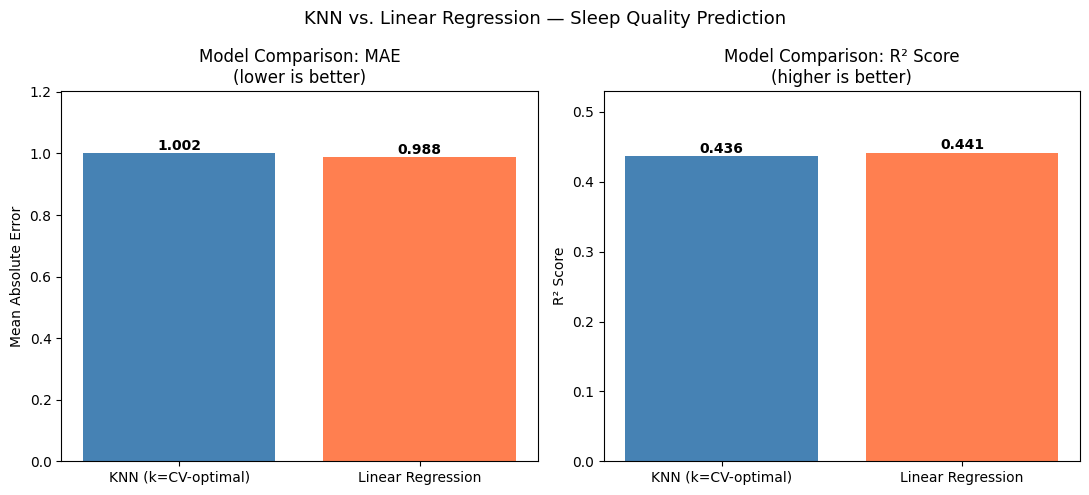

In [35]:
# Side-by-side model comparison
models     = ['KNN (k=CV-optimal)', 'Linear Regression']
mae_scores = [mae_cv,  mae_lr]
r2_scores  = [r2_cv,   r2_lr]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].bar(models, mae_scores, color=['steelblue', 'coral'])
axes[0].set_title('Model Comparison: MAE\n(lower is better)')
axes[0].set_ylabel('Mean Absolute Error')
axes[0].set_ylim(0, max(mae_scores) * 1.2)
for i, v in enumerate(mae_scores):
    axes[0].text(i, v + 0.01, str(round(v, 3)), ha='center', fontweight='bold')

axes[1].bar(models, r2_scores, color=['steelblue', 'coral'])
axes[1].set_title('Model Comparison: R² Score\n(higher is better)')
axes[1].set_ylabel('R² Score')
axes[1].set_ylim(0, max(r2_scores) * 1.2)
for i, v in enumerate(r2_scores):
    axes[1].text(i, v + 0.005, str(round(v, 3)), ha='center', fontweight='bold')

plt.suptitle('KNN vs. Linear Regression — Sleep Quality Prediction', fontsize=13)
plt.tight_layout()
plt.show()

**Model Comparison:**

The bar charts above directly compare KNN and Linear Regression on MAE and R².
If KNN achieves a meaningfully lower MAE and higher R², this confirms that
non-linear interactions between our features matter, which alings with our
hypothesis that the relationship between lifestyle habits and sleep quality
is not purely linear.


---
## Summary, Insights & Discussion

### What We Set Out to Answer

This project investigated two questions about student sleep quality: whether a
measurable screen time threshold exists beyond which sleep degrades, and whether
sleep quality can be predicted from a set of lifestyle variables. Together, these
questions first characterized the
relationship between screen time and sleep, then quantified it within a model.

### What We Found

**Research Question 1: The Screen-Time Cutoff:**
Our hypothesis testing in Step 5 confirmed that mean sleep quality begins to drop
meaningfully at the 4–6 hour screen time bin, with statistically significant
differences emerging at 6h+. This supports our hypothesis of a non-linear threshold: moderate screen use (under ~4 hours/day) shows limited impact, but heavy
use crosses a threshold that is reliably associated with lower sleep quality across
both datasets.

**Research Question 2: Predicting Sleep Quality:**
Both models achieved comparable predictive performance, but the outcome was
the opposite of what we hypothesized.
Linear Regression marginally outperformed KNN on both metrics. This is a meameaningful
finding: it suggests that the relationship between our four features and sleep quality
is largely linear, and that KNN's ability to capture non-linear interactions did
not provide a meaningful advantage here. The added complexity of a nearest-neighbor
approach did not translate into better predictions.

The Linear Regression coefficients tell which variables matter
and how:

- **`screen_time_hrs`: –1.203**: by far the most influential predictor. Each
  additional hour of daily screen time is associated with a drop of approximately
  1.2 points on the sleep quality scale, holding all other variables constant.
  This is a large effect and directly confirms the central idea of our project.
- **`sleep_hours`: +0.017**: a small but positive relationship: longer sleep
  duration is weakly associated with better quality scores. The small number
  suggests these two measures, while correlated, measure different aspects of sleep.
- **`caffeine_mg`: –0.029**: a mild negative effect. Caffeine intake is
  associated with slightly lower sleep quality, though the effect is a lot smaller
  relative to screen time.
- **`physical_activity_hrs`: –0.006**: near zero and slightly negative, which
  is counterintuitive. We expected physical activity to be a protective factor.
  The near-zero coefficient suggests that, once screen time and sleep hours are
  accounted for, physical activity adds little additional predictive power for
  sleep quality in this dataset.

### Unexpected Insights

The most surprising finding is that Linear Regression outperformed KNN. We
hypothesized non-linear interactions would make KNN the stronger model, but the
data did not support this. The dominant effect of `screen_time_hrs`  essentially means sleep quality is being
driven by one variable in a fairly direct, linear way.

The physical activity coefficient was also unexpected. Research generally
supports exercise as beneficial for sleep, yet the coefficient here is slightly
negative. This could be due to things like overreporting of exercise hours, or innacurate data.

### Limitations & Future Work

The R² of ~0.44 across
both models is a clear signal that the majority of variation in sleep quality is
most likely driven by factors we did not measure: genetics, mental health, sleep disorders,
room environment, and daily stress.

**Future work could:**

- Incorporate objective sleep data from wearables rather than self-report scores
- Add mental health and stress variables, which are likely strong confounders
- Use a longitudinal design to track whether changes in screen time within the
  same individual predict changes in their sleep quality over time

# Additional Resources


1.   [Wickham Tidy Data](https://vita.had.co.nz/papers/tidy-data.pdf)

2.   [Stress and Mood Associations with Smartphone Use in University Students: A 12-Week Longitudal Study](https://pmc.ncbi.nlm.nih.gov/articles/PMC10491487/)

3. [Development and validation of an explainable machine learning model for predicting the risk of sleep disorders in older adults with multimorbidity: a cross-sectional study](https://pmc.ncbi.nlm.nih.gov/articles/PMC12375460/)

4. [Dataset 1](https://www.kaggle.com/datasets/arsalanjamal002/student-sleep-patterns)

5. [Dataset 2](https://www.kaggle.com/datasets/jayjoshi37/sleep-screen-time-and-stress-analysis)



In [36]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed

In [ ]:
%%shell
jupyter nbconvert --to html "/content/drive/MyDrive/Colab Notebooks/Final_Analysis_DS.ipynb"